In [1]:
# Google Drive mount

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

def set_default_directory(directory):
    """
    기본 작업 디렉토리를 설정하는 함수
    """
    os.chdir(directory)
    print("현재 작업 디렉토리를 설정했습니다:", os.getcwd())

In [3]:
# ipynb 파일이 있는 위치로 경로 설정
drive_path = '/content/drive/MyDrive/chapter10'
set_default_directory(drive_path)

현재 작업 디렉토리를 설정했습니다: /content/drive/MyDrive/chapter10


# Exercise 1 : Gender Recognition

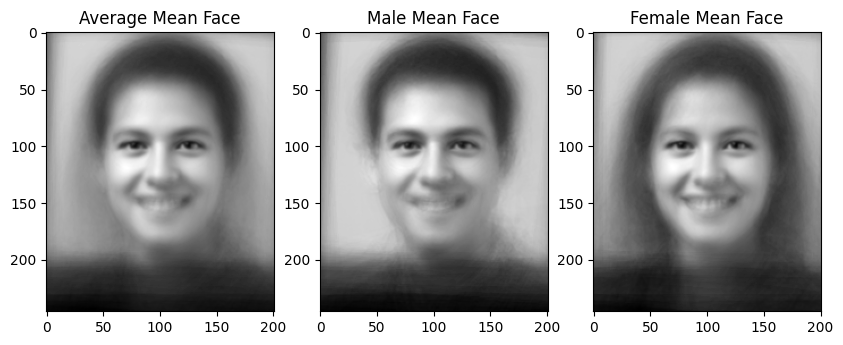

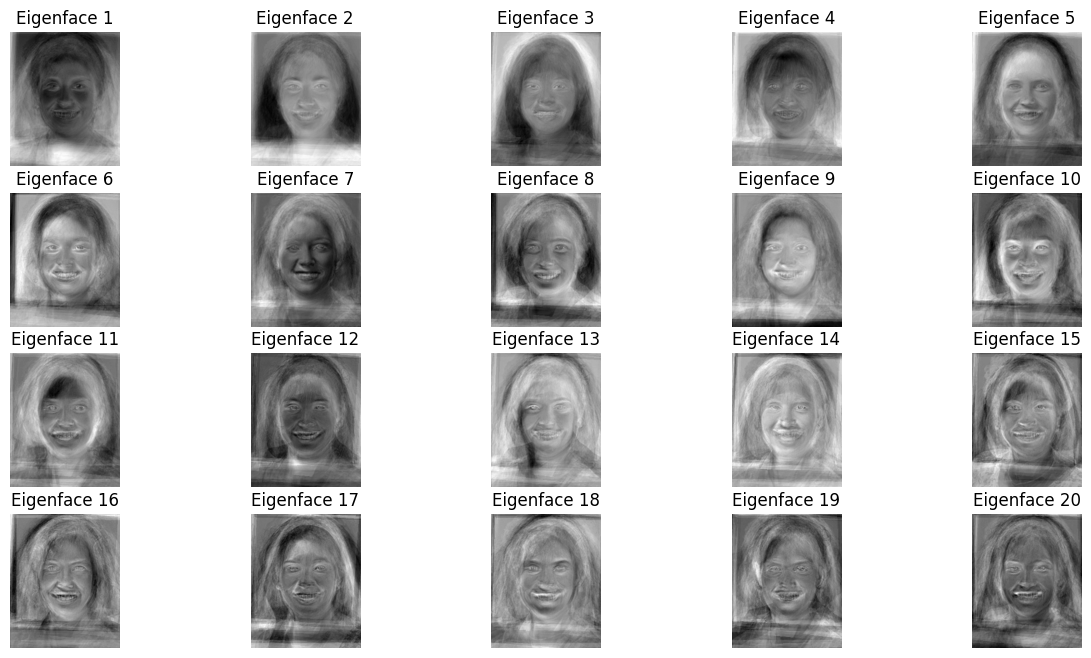

In [16]:
import numpy as np
import cv2
import os
from sklearn.decomposition import PCA
from matplotlib import pyplot as plt
# Helper function to list files in a directory with a specific extension
def list_files(directory, extension):
    return (f for f in os.listdir(directory) if f.endswith('.' + extension))
# Get images
alignLabel = '_aligned/Data_aligned'
dataFolders = [f'Data{alignLabel}/Male', f'Data{alignLabel}/Female']
imageFiles = [[os.path.join(folder, f) for f in list_files(folder, 'jpg')] for folder in dataFolders]
# Split into training and testing indices
trainingIndices = slice(0, None, 2)  # Even indices
testingIndices = slice(1, None, 2)   # Odd indices
# Compute mean faces
meanFaces = []
for files in imageFiles:
    images = [cv2.imread(file, cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255 for file in files[trainingIndices]]
    meanFace = np.mean(images, axis=0)
    meanFaces.append(meanFace)
# Display mean faces
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.imshow(0.5 * (meanFaces[0] + meanFaces[1]), cmap='gray')
plt.title('Average Mean Face')
plt.subplot(1, 3, 2)
plt.imshow(meanFaces[0], cmap='gray')
plt.title('Male Mean Face')
plt.subplot(1, 3, 3)
plt.imshow(meanFaces[1], cmap='gray')
plt.title('Female Mean Face')
plt.show()
# Compute eigenfaces using PCA
pca = PCA(n_components=20)  # 20 components
pca.fit(np.vstack([img.ravel() for img in images]))  # Fit on flattened images
eigenfaces = pca.components_.reshape((20, *images[0].shape))
# Display eigenfaces
plt.figure(figsize=(15, 8))
for i, eigenface in enumerate(eigenfaces, 1):
    plt.subplot(4, 5, i)
    plt.imshow(eigenface, cmap='gray')
    plt.title(f'Eigenface {i}')
    plt.axis('off')
plt.show()

# Exercise 2 : Illumination Variations

In [4]:
import cv2
import os

def extract_frames(video_path, output_folder, frame_rate=1):
    # Create the output folder if it doesn't exist
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    # Load the video
    video = cv2.VideoCapture(video_path)
    fps = video.get(cv2.CAP_PROP_FPS)  # Frames per second
    interval = int(fps / frame_rate)  # Calculate interval between frames to capture

    frame_count = 0
    while True:
        success, frame = video.read()
        if not success:
            break  # No more frames or error

        # Save frame at specific interval
        if frame_count % interval == 0:
            frame_id = frame_count // interval
            frame_path = os.path.join(output_folder, f"frame_{frame_id}.jpg")
            cv2.imwrite(frame_path, frame)
            print(f"Saved {frame_path}")

        frame_count += 1

    video.release()
    print("Done extracting frames.")

# Example usage
video_file_path = 'light.mpg'
output_directory = 'extracted_frames'
extract_frames(video_file_path, output_directory)


Saved extracted_frames/frame_0.jpg
Saved extracted_frames/frame_1.jpg
Saved extracted_frames/frame_2.jpg
Saved extracted_frames/frame_3.jpg
Saved extracted_frames/frame_4.jpg
Saved extracted_frames/frame_5.jpg
Done extracting frames.


In [6]:
from PIL import Image
import os

def crop_images(input_folder, output_folder, start_frame, end_frame, crop_box):
    # Ensure the output folder exists
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    # Loop through the frame range
    for nFrame in range(start_frame, end_frame + 1):
        # Format the filename
        filename = f"frame_{nFrame:06d}.jpg"
        input_path = os.path.join(input_folder, filename)

        # Read the image
        try:
            with Image.open(input_path) as img:
                # Crop the image
                cropped_img = img.crop(crop_box)

                # Save the cropped image
                output_path = os.path.join(output_folder, filename)
                cropped_img.save(output_path)
                print(f"Cropped image saved to {output_path}")
        except FileNotFoundError:
            print(f"No file found for {input_path}. Skipping...")
        except Exception as e:
            print(f"Error processing {input_path}: {e}")

# Example usage
input_folder = 'keyframes/keyframes'
output_folder = 'keyframes_cropped/keyframes_cropped'
start_frame = 139
end_frame = 150
crop_box = (73, 27, 209, 204)  # (left, upper, right, lower)

crop_images(input_folder, output_folder, start_frame, end_frame, crop_box)


Cropped image saved to keyframes_cropped/keyframes_cropped/frame_000139.jpg
Cropped image saved to keyframes_cropped/keyframes_cropped/frame_000140.jpg
Cropped image saved to keyframes_cropped/keyframes_cropped/frame_000141.jpg
Cropped image saved to keyframes_cropped/keyframes_cropped/frame_000142.jpg
Cropped image saved to keyframes_cropped/keyframes_cropped/frame_000143.jpg
Cropped image saved to keyframes_cropped/keyframes_cropped/frame_000144.jpg
Cropped image saved to keyframes_cropped/keyframes_cropped/frame_000145.jpg
Cropped image saved to keyframes_cropped/keyframes_cropped/frame_000146.jpg
Cropped image saved to keyframes_cropped/keyframes_cropped/frame_000147.jpg
Cropped image saved to keyframes_cropped/keyframes_cropped/frame_000148.jpg
Cropped image saved to keyframes_cropped/keyframes_cropped/frame_000149.jpg
Cropped image saved to keyframes_cropped/keyframes_cropped/frame_000150.jpg


# Exercise 3 : Person Identification

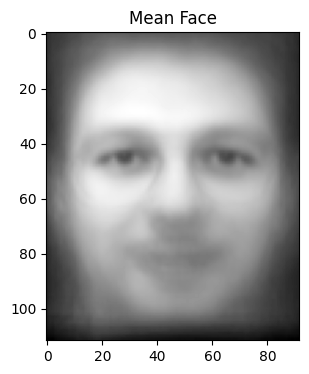

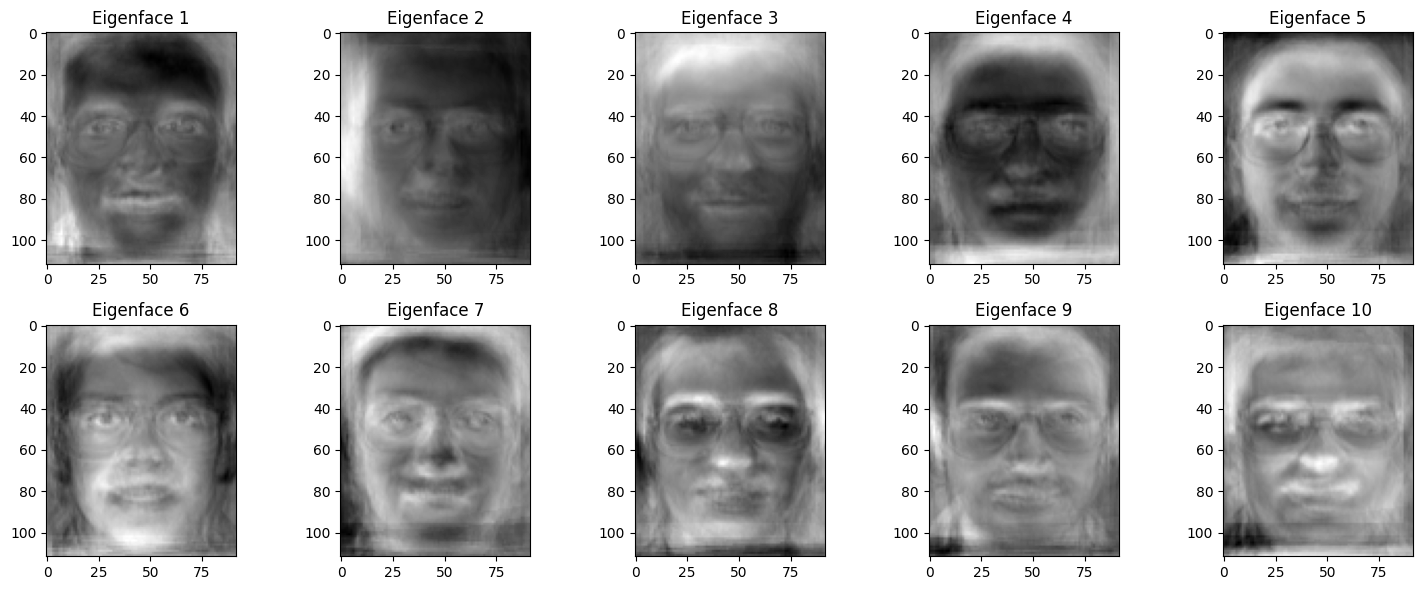

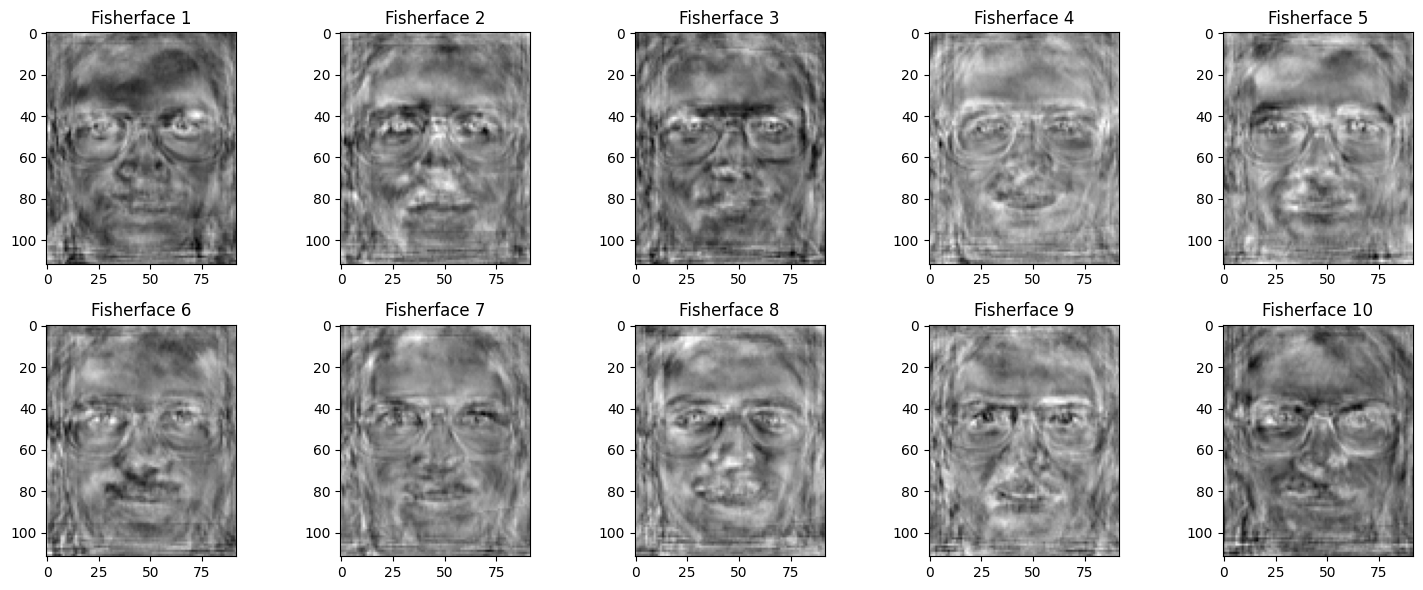

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Directory and image size settings
face_dir = 'att_faces_aligned_lighting/att_faces_aligned_lighting'
height, width = 112, 92
num_classes = 40
training_range = range(1, 6)
testing_range = range(6, 11)

# Loading images and labels

def load_images(ranges):
    images = []
    labels = []
    for nClass in range(1, num_classes + 1):
        for idx in ranges:
            file_path = os.path.join(face_dir, f's{nClass}', f'{idx}.pgm')
            img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                print(f"Failed to load image: {file_path}")
                continue
            img = img.astype(np.float64) / 255  # Normalize to [0,1]
            images.append(img.ravel())  # Flatten the image
            labels.append(nClass)
    return np.array(images), np.array(labels)

# Load training data
train_images, train_labels = load_images(training_range)

# PCA Calculation
pca = PCA(n_components=150)  # You can adjust the number of components
train_pca = pca.fit_transform(train_images)

# Display mean face
plt.figure(figsize=(4, 4))
plt.imshow(pca.mean_.reshape(height, width), cmap='gray')
plt.title('Mean Face')
plt.show()

# LDA Calculation
lda = LDA()
train_lda = lda.fit_transform(train_pca, train_labels)  # Apply LDA on PCA features

# Display Eigenfaces
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(pca.components_[i].reshape(height, width), cmap='gray')
    ax.set_title(f'Eigenface {i+1}')
plt.tight_layout()
plt.show()

# Display Fisherfaces
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flatten()):
    # Correctly perform matrix multiplication
    fisherface = np.dot(lda.scalings_[:, i].reshape(1, -1), pca.components_[:150]).reshape(height, width)
    ax.imshow(fisherface, cmap='gray')
    ax.set_title(f'Fisherface {i+1}')
plt.tight_layout()
plt.show()



In [8]:
import numpy as np

def add_illumination(img):
    height, width = img.shape
    x, y = np.meshgrid(np.arange(1, width+1), np.arange(1, height+1))
    a = 5 * (np.random.rand() - 0.5) / width
    b = 5 * (np.random.rand() - 0.5) / height
    theta = 0.2
    img_out = img * (1 - theta + theta * np.cos(a * x + b * y))
    return img_out


In [11]:
import numpy as np
import cv2
import os

def add_illumination(img):
    height, width = img.shape
    x, y = np.meshgrid(np.arange(1, width+1), np.arange(1, height+1))
    a = 5 * (np.random.rand() - 0.5) / width
    b = 5 * (np.random.rand() - 0.5) / height
    theta = 0.2
    img_out = img * (1 - theta + theta * np.cos(a * x + b * y))
    return img_out

input_dir = 'att_faces_aligned/att_faces_aligned'
output_dir = 'att_faces_aligned_lighting/att_faces_aligned_lighting'

# Ensure output directories exist
os.makedirs(output_dir, exist_ok=True)
for i in range(1, 41):
    os.makedirs(os.path.join(output_dir, f's{i}'), exist_ok=True)

# Process each image
for i in range(1, 41):
    for j in range(1, 11):
        file_path = os.path.join(input_dir, f's{i}', f'{j}.pgm')
        img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            print(f"Failed to load image: {file_path}")
            continue
        img = img.astype(np.float64) / 255  # Normalize to [0,1]
        img = add_illumination(img)
        img = (img * 255).astype(np.uint8)  # Convert back to 0-255 scale for saving

        # Save as PGM and JPG
        cv2.imwrite(os.path.join(output_dir, f's{i}', f'{j}.pgm'), img)
        cv2.imwrite(os.path.join(output_dir, f's{i}', f'{j}.jpg'), img)


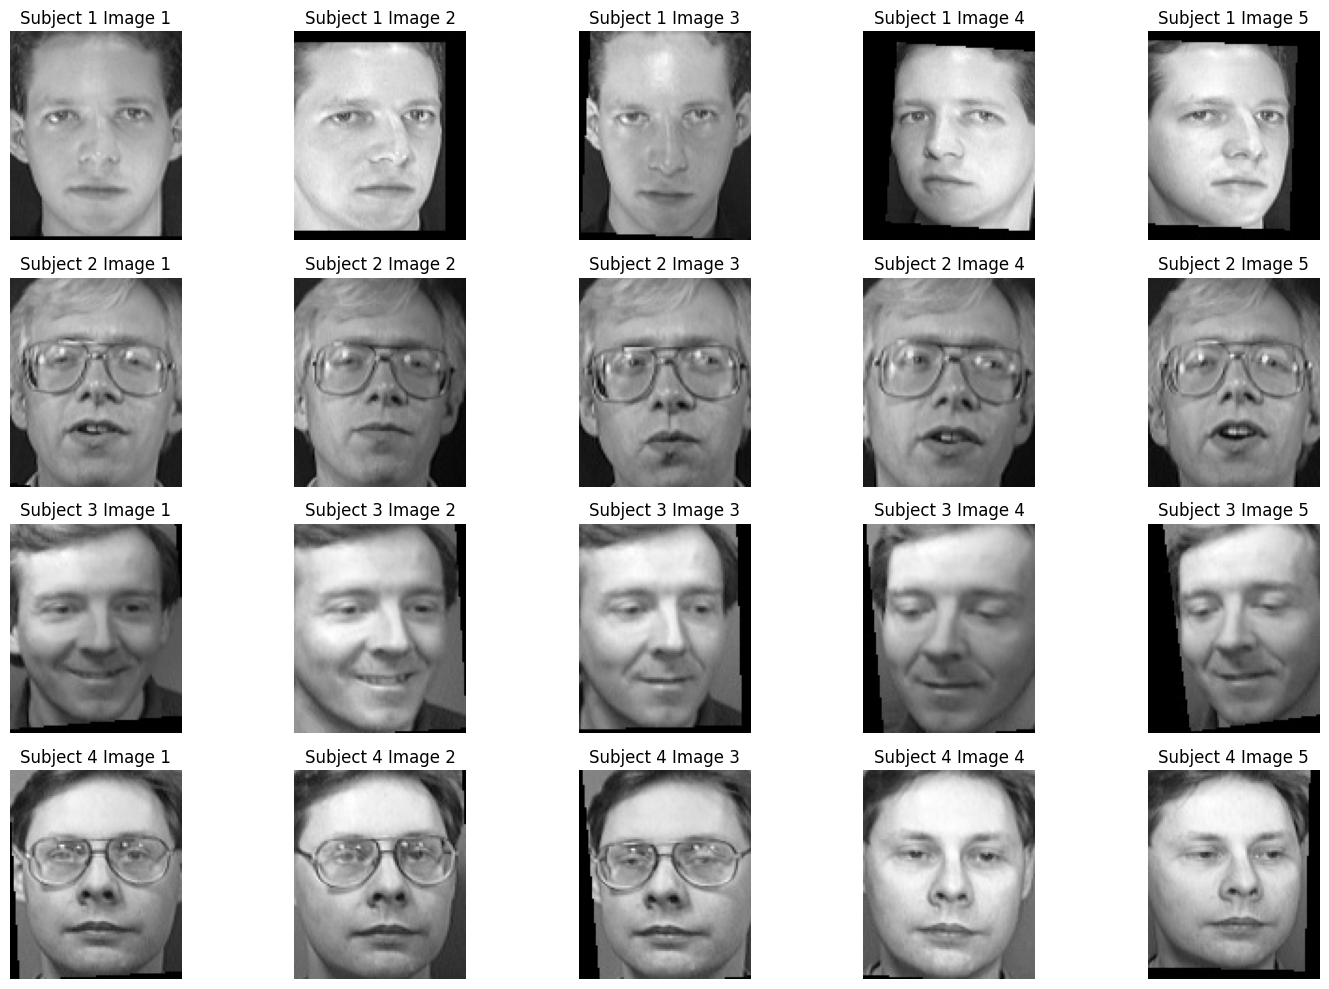

In [15]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt

def add_illumination(img):
    height, width = img.shape
    x, y = np.meshgrid(np.arange(1, width+1), np.arange(1, height+1))
    a = 5 * (np.random.rand() - 0.5) / width
    b = 5 * (np.random.rand() - 0.5) / height
    theta = 0.2
    img_out = img * (1 - theta + theta * np.cos(a * x + b * y))
    return img_out

input_dir = 'att_faces_aligned/att_faces_aligned'
output_dir = 'att_faces_aligned_lighting/att_faces_aligned_lighting'

# Ensure output directories exist
os.makedirs(output_dir, exist_ok=True)
for i in range(1, 41):
    os.makedirs(os.path.join(output_dir, f's{i}'), exist_ok=True)

# Process each image
for i in range(1, 41):
    for j in range(1, 11):
        file_path = os.path.join(input_dir, f's{i}', f'{j}.pgm')
        img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            print(f"Failed to load image: {file_path}")
            continue
        img = img.astype(np.float64) / 255  # Normalize to [0,1]
        img = add_illumination(img)
        img = (img * 255).astype(np.uint8)  # Convert back to 0-255 scale for saving

        # Save as PGM and JPG
        cv2.imwrite(os.path.join(output_dir, f's{i}', f'{j}.pgm'), img)
        cv2.imwrite(os.path.join(output_dir, f's{i}', f'{j}.jpg'), img)

# Visualization of some processed images
fig, axs = plt.subplots(nrows=4, ncols=5, figsize=(15, 10))  # Change grid size based on how many images you want to show
axs = axs.flatten()
index = 0

for i in range(1, 5):  # Example: Show images from first 4 subjects
    for j in range(1, 6):  # Example: Show first 5 images of each subject
        img_path = os.path.join(output_dir, f's{i}', f'{j}.jpg')
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        axs[index].imshow(img, cmap='gray')
        axs[index].axis('off')
        axs[index].set_title(f'Subject {i} Image {j}')
        index += 1

plt.tight_layout()
plt.show()
